# 第 3+4 步「denoiser 训练 + 采样」

配套讲解文档：`../../simulation_tutorial.html` 第 3、4 节。

- **第 3 步（训练）**：让网络 `ε_θ(x_t,t)` 学会从带噪样本预测当初加进去的噪声 `ε`。
- **第 4 步（采样）**：把训好的网络反过来用，从纯噪声 `x_T~N(0,I)` 一步步去噪生成新样本。

> ⚠️ **本 notebook 用论文严格配置**（65536 样本 × 20 epoch）。在 CPU 上约需 **5 小时**，强烈建议在 **GPU** 上运行
> （论文用 A100，约几分钟）。代码会自动检测 CUDA。训练完会存 checkpoint，第 5 步（引导/DPS）直接复用。
> 等价命令行见下方。需要装好 `requirements.txt`。

In [2]:
# ---- 环境准备 ----
%matplotlib inline
import os, sys, time
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# 选用哪张 GPU（必须在 import torch 之前设置；改完要 Kernel→Restart 从头运行才生效）。
# 填物理卡编号（用 `nvidia-smi` 看哪张最空，当前 2/3 号利用率最低）。
# 设了之后被选中的卡在进程内即为 cuda:0，连 train.py 里写死的 cuda:0 也会落到这张卡。
# 想用全部卡 / 回到默认行为，把下面一行注释掉即可。
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# 自动定位 simulations 目录（含 train.py），无论本 notebook 放在哪层文件夹
_here = os.getcwd()
_cands = [_here, os.path.dirname(_here),
          os.path.join(_here, "simulations"),
          os.path.join(os.path.dirname(_here), "simulations"),
          r"H:\My Drive\Research\DAM\code\GGDMOptim\simulations"]
SIM_DIR = next((c for c in _cands if os.path.exists(os.path.join(c, "train.py"))), _here)
os.chdir(SIM_DIR); sys.path.insert(0, SIM_DIR)

import numpy as np, torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from unet_1d import Unet1D
from diffusion import GuidedGaussianDiffusion, extract
from train import LinearLatentData, SingleStepIterator, set_seed

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
set_seed(2345)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device,
      "| CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"),
      "| 进程可见卡数:", torch.cuda.device_count() if torch.cuda.is_available() else 0)

g = LinearLatentData("data/linear_latent/hyperparameters.npz", d_inner=16, d_outer=64, r_off=9)
M = g.A.T @ g.A

# 无条件 denoiser（conditional=False：引导靠采样时改 score，不靠条件网络）
model = Unet1D(dim=64, conditional=False)
diff  = GuidedGaussianDiffusion(model=model, image_size=64, timesteps=200)
diff.to(device)
n_params = sum(p.numel() for p in diff.model.parameters())
print("Unet1D 参数量: %.2fM | T=%d" % (n_params/1e6, diff.num_timesteps))

device: cuda | CUDA_VISIBLE_DEVICES = 2 | 进程可见卡数: 1
Unet1D 参数量: 14.86M | T=200


## 第 3 步 · 训练目标

把一个真实样本 `x_0` 随机加噪到某个 `t`，让网络预测加进去的噪声 `ε`：
$$\mathcal L(\theta)=\mathbb E_{x_0,\,t,\,\varepsilon}\big\|\varepsilon_\theta(x_t,t)-\varepsilon\big\|^2,\qquad x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$$
"预测噪声"等价于"学 score"：`s(x_t,t) = -ε_θ/√(1-ᾱ_t)`。

对应代码：`diffusion.py` 的 `forward()`（随机抽 t）→ `p_losses()`（加噪 + MSE，L109）。
训练循环直接用仓库的 `SingleStepIterator`（即 `main.py` 的 `pretrain()` 逻辑）。

## 第 3 步 · 训练（论文配置）

| 参数 | 论文值 | 代码 |
|---|---|---|
| 初始数据集大小 N₀ | 65536 | `--N_0` |
| epoch 数 | 20 | `--pre_num_episodes` |
| batch size | 32 | `--pre_bs` |
| 学习率 | 1e-4 | `--pre_lr` |
| 时间步 T | 200 | `--T` |

**等价命令行**（README）：
```
python main.py --x_type linear_latent --pretrain --pre_lr 1e-4 \
  --pre_num_episodes 20 --pre_bs 32 \
  --pretrain_ckpt_folder checkpoints/pretrained
```
下面的 cell 做同样的事，并把 loss 曲线画出来、存 checkpoint。已有 checkpoint 时直接加载、跳过训练。

In [ ]:
# 论文严格配置
N0, EPOCHS, BS, LR = 65536, 20, 32, 1e-4
CKPT = "checkpoints/pretrained/linear_latent_pretrain_d64_epoch_20.pth"

if os.path.exists(CKPT):
    info = torch.load(CKPT, map_location=device)
    diff.load_state_dict(info["model_state_dict"])
    print("已加载现成 checkpoint:", CKPT, "| epoch", info.get("epoch"))
    losses = None
else:
    print(f"未发现 checkpoint，开始训练 (N0={N0}, epochs={EPOCHS})...")
    set_seed(2345)
    data = torch.from_numpy(g.generate_x(N0)).float()
    loader = DataLoader(TensorDataset(data), batch_size=BS)
    opt = torch.optim.Adam(diff.model.parameters(), lr=LR, betas=(0.9, 0.99))

    diff.train()
    trainer = SingleStepIterator(diff, opt, log_dir="logs/notebook_pretrain")  # 仓库训练器
    t0 = time.time()
    trainer.train(loader, num_episodes=EPOCHS)                                  # = main.py pretrain
    print("训练耗时 %.1f 分钟" % ((time.time()-t0)/60))
    losses = trainer.stats["loss_diffusion"]

    # 存 checkpoint（格式同 main.py save_checkpoint）
    os.makedirs(os.path.dirname(CKPT), exist_ok=True)
    torch.save({"x_type": "linear_latent", "epoch": EPOCHS,
                "model_state_dict": diff.state_dict()}, CKPT)
    print("已保存 checkpoint:", CKPT)

未发现 checkpoint，开始训练 (N0=65536, epochs=20)...
⚠️ CPU 上约 5 小时；GPU 上约几分钟。


diffusion training epoch 0:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 1:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 2:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 3:   0%|          | 0/2048 [00:00<?, ?it/s]

...

diffusion training epoch 16:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 17:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 18:   0%|          | 0/2048 [00:00<?, ?it/s]

diffusion training epoch 19:   0%|          | 0/2048 [00:00<?, ?it/s]

训练耗时 54.5 分钟
已保存 checkpoint: checkpoints/pretrained/linear_latent_pretrain_epoch_20.pth


In [ ]:
# loss 曲线（仅当本次实际训练了才有）
if losses is not None:
    losses = np.array(losses)
    plt.figure(figsize=(8, 4))
    plt.plot(losses, alpha=0.3, label="per-step loss")
    # 滑动平均看趋势
    k = max(1, len(losses)//200)
    smooth = np.convolve(losses, np.ones(k)/k, mode="valid")
    plt.plot(np.arange(len(smooth)), smooth, lw=2, label=f"moving avg ({k})")
    plt.xlabel("training step"); plt.ylabel(r"MSE loss  $\|\epsilon_\theta-\epsilon\|^2$"); plt.legend()
    plt.title("denoiser training loss (decreasing = better noise prediction)"); plt.yscale("log")
    plt.tight_layout(); plt.show()
    print("首/末步 loss: %.4f → %.4f" % (losses[0], losses[-1]))
else:
    print("加载了现成 checkpoint，无本次训练 loss 曲线。")

## 第 4 步 · 无条件采样：从噪声生成数据

把训好的 denoiser 反过来用：`x_T~N(0,I)` → 逐步去噪 → `x_0`。
对应 `diffusion.py`：`sample()`(L99) → `p_sample()`(L92) → `p_mean_variance()`(L81)。

**验证目标**：生成样本的 off-support ratio 应 ≈ 0（落在 16 维流形上），和第 1/2 步的锚点对照
（真实数据≈0，纯噪声≈√3）。

In [18]:
# ---- 第 4 步独立启动：补齐采样所需的全部依赖 ----
# 用法：第 3 步训练（或之前已训练）完成、checkpoint 已存在后，
#   · 想从头跑：直接顺着跑下来，这格会跳过环境重建、只重新加载同一份权重（幂等）。
#   · 重启 kernel 后只想做采样：Kernel→Restart，然后从这一格开始往下跑即可，无需重跑第 1~3 步。

# 1) 基础环境（仅在 kernel 里还没有 diff/g/M/device 时才重建）
#    注意：CUDA_VISIBLE_DEVICES 必须在 import torch 之前设，所以放在 except 分支里。
try:
    diff, g, M, device  # 前面已经跑过 → 直接复用，不重建
    print("检测到已有 diff/g/M/device，跳过环境重建。")
except NameError:
    import os, sys
    os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
    os.environ["CUDA_VISIBLE_DEVICES"] = "2"   # 与第 1 步保持一致；想换卡改这里
    _here = os.getcwd()
    _cands = [_here, os.path.dirname(_here),
              os.path.join(_here, "simulations"),
              os.path.join(os.path.dirname(_here), "simulations")]
    SIM_DIR = next((c for c in _cands if os.path.exists(os.path.join(c, "train.py"))), _here)
    os.chdir(SIM_DIR); sys.path.insert(0, SIM_DIR)

    import numpy as np, torch
    import matplotlib.pyplot as plt
    from unet_1d import Unet1D
    from diffusion import GuidedGaussianDiffusion, extract
    from train import LinearLatentData, set_seed
    plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(2345)
    g = LinearLatentData("data/linear_latent/hyperparameters.npz",
                         d_inner=16, d_outer=64, r_off=9)
    M = g.A.T @ g.A
    model = Unet1D(dim=64, conditional=False)        # 必须和第 1 步同构，才能 load 权重
    diff  = GuidedGaussianDiffusion(model=model, image_size=64, timesteps=200)
    diff.to(device)
    print("环境/模型已重建 | device:", device,
          "| 可见卡数:", torch.cuda.device_count() if torch.cuda.is_available() else 0)

# 2) 加载训练好的权重（无论上面走哪条分支都执行，保证 diff 用的是训练后的参数）
import os, torch
CKPT = "checkpoints/pretrained/linear_latent_pretrain_d64_epoch_20.pth"
assert os.path.exists(CKPT), (
    f"找不到 checkpoint：{CKPT}\n请先完成第 3 步训练（或确认路径正确）再跑采样。")
info = torch.load(CKPT, map_location=device)
diff.load_state_dict(info["model_state_dict"])
diff.eval()
print("已加载训练好的权重:", CKPT, "| epoch", info.get("epoch"))


检测到已有 diff/g/M/device，跳过环境重建。


/tmp/ipykernel_3948433/4121422319.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  info = torch.load(CKPT, map_location=device)


已加载训练好的权重: checkpoints/pretrained/linear_latent_pretrain_d64_epoch_20.pth | epoch 20


In [19]:
diff.eval()
set_seed(0)
with torch.no_grad():
    samples = diff.sample(num_samples=2000)          # 无条件采样
samples_np = samples.cpu().numpy()

r_samp = g.off_support_ratio(samples_np)
r_data = g.off_support_ratio(g.generate_x(2000))     # 真实数据锚点
print("生成样本 off-ratio mean=%.3f  (真实数据≈%.3f, 纯噪声≈√3=1.73)"
      % (r_samp.mean(), r_data.mean()))
print("生成样本 ‖x‖ mean=%.2f  (真实数据≈√16=4)" % np.linalg.norm(samples_np, axis=1).mean())


sampling:   0%|          | 0/200 [00:00<?, ?it/s]

生成样本 off-ratio mean=0.039  (真实数据≈0.000, 纯噪声≈√3=1.73)
生成样本 ‖x‖ mean=3.77  (真实数据≈√16=4)


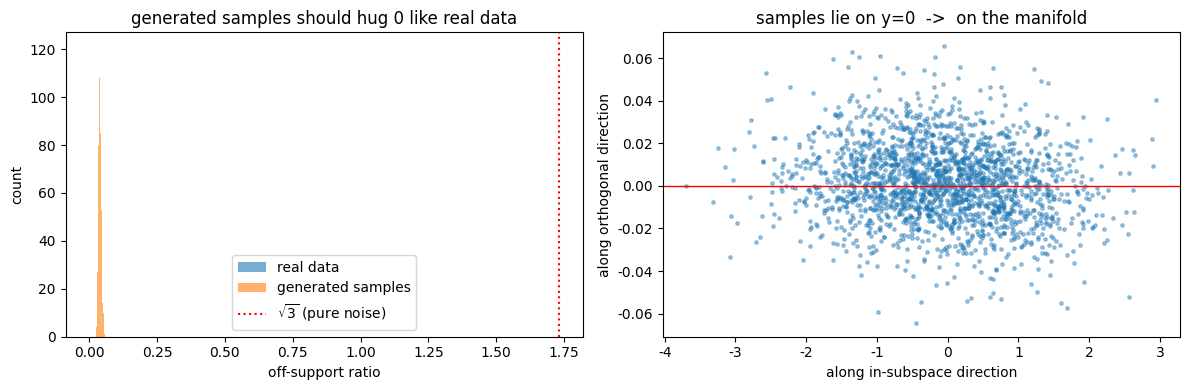

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(r_data, bins=50, alpha=0.6, label="real data")
ax[0].hist(r_samp, bins=50, alpha=0.6, label="generated samples")
ax[0].axvline(np.sqrt(3), color="r", ls=":", label=r"$\sqrt{3}$ (pure noise)")
ax[0].set_xlabel("off-support ratio"); ax[0].set_ylabel("count"); ax[0].legend()
ax[0].set_title("generated samples should hug 0 like real data")

# 2D 投影：生成样本是否贴在 y=0（流形）上
in_dir = g.A[0] / np.linalg.norm(g.A[0])
rv = np.random.randn(64); rv = rv - rv @ M; off_dir = rv / np.linalg.norm(rv)
ax[1].scatter(samples_np @ in_dir, samples_np @ off_dir, s=6, alpha=0.4)
ax[1].axhline(0, color="r", lw=1)
ax[1].set_xlabel("along in-subspace direction"); ax[1].set_ylabel("along orthogonal direction")
ax[1].set_title("samples lie on y=0  ->  on the manifold")
plt.tight_layout(); plt.show()

### 反向轨迹：采样是加噪的逆过程

记录一次采样中 `x_t` 的 off-ratio 随 t 从 T→0 的变化：应从 √3（纯噪声）一路降到 0（流形上），
正好和第 2 步的加噪曲线**反着走**。

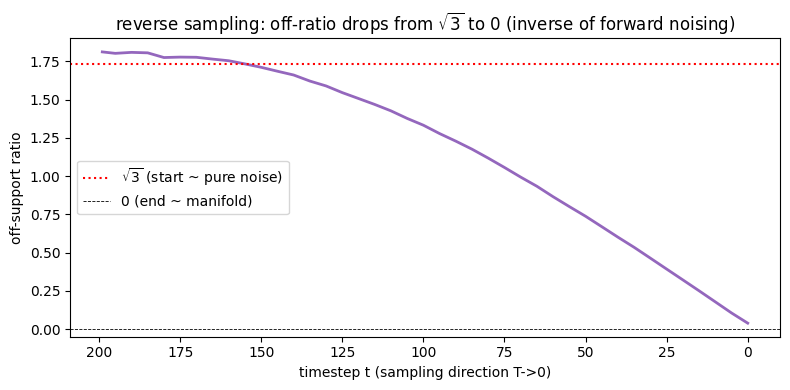

In [21]:
@torch.no_grad()
def sample_with_trace(n=1000):
    img = torch.randn((n, diff.image_size), device=device)
    trace = []
    for t in range(diff.num_timesteps - 1, -1, -1):
        img = diff.p_sample(img, t)
        if t % 5 == 0 or t == diff.num_timesteps - 1:
            trace.append((t, g.off_support_ratio(img.cpu().numpy()).mean()))
    return np.array(trace)

set_seed(1)
tr = sample_with_trace(1000)
plt.figure(figsize=(8, 4))
plt.plot(tr[:, 0], tr[:, 1], lw=2, color="tab:purple")
plt.axhline(np.sqrt(3), color="r", ls=":", label=r"$\sqrt{3}$ (start ~ pure noise)")
plt.axhline(0, color="k", lw=0.6, ls="--", label="0 (end ~ manifold)")
plt.gca().invert_xaxis()                              # t 从 T→0
plt.xlabel("timestep t (sampling direction T->0)"); plt.ylabel("off-support ratio")
plt.title(r"reverse sampling: off-ratio drops from $\sqrt{3}$ to 0 (inverse of forward noising)"); plt.legend()
plt.tight_layout(); plt.show()

## 验证 denoiser 质量 · Tweedie 恢复

直接测"网络会不会预测噪声"：取真实 `x_0` 加噪到不同 `t` → 网络预测噪声 → 用 Tweedie 还原 `x̂_0`。
- **低 t**：噪声少，`x̂_0` 应非常接近真 `x_0`（相对误差小）
- **高 t**：信息基本被噪声淹没，`x̂_0` 只能塌向数据的"平均猜测"（误差大）

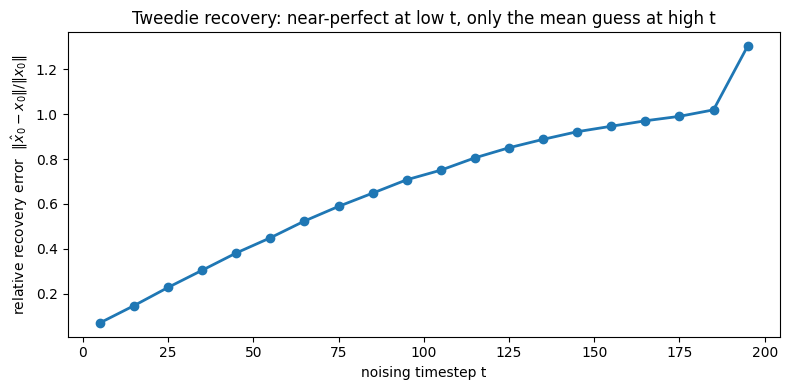

t=5 相对误差=0.069  | t=195 相对误差=1.304


In [22]:
diff.eval()
x0 = torch.from_numpy(g.generate_x(1000)).float().to(device)
ts = list(range(5, 200, 10))
rel_err = []
with torch.no_grad():
    for t in ts:
        tt = torch.full((x0.shape[0],), t, device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        xt = (extract(diff.sqrt_alphas_cumprod, tt, x0.shape) * x0
              + extract(diff.sqrt_one_minus_alphas_cumprod, tt, x0.shape) * eps)
        pred = diff.model(xt, tt, None)
        x0_hat = (extract(diff.sqrt_recip_alphas_cumprod, tt, xt.shape) * xt
                  - extract(diff.sqrt_recipm1_alphas_cumprod, tt, xt.shape) * pred)
        rel_err.append(((x0_hat - x0).norm(dim=1) / x0.norm(dim=1)).mean().item())

plt.figure(figsize=(8, 4))
plt.plot(ts, rel_err, marker="o", lw=2)
plt.xlabel("noising timestep t"); plt.ylabel(r"relative recovery error  $\|\hat x_0 - x_0\|/\|x_0\|$")
plt.title("Tweedie recovery: near-perfect at low t, only the mean guess at high t")
plt.tight_layout(); plt.show()
print("t=5 相对误差=%.3f  | t=195 相对误差=%.3f" % (rel_err[0], rel_err[-1]))

## 小结

| 步骤 | 验证 |
|---|---|
| 训练 | loss 下降 → 网络越来越会预测噪声 |
| 采样 | 生成样本 off-ratio ≈ 0、贴在 y=0 → 落在流形上 |
| 反向轨迹 | off-ratio 从 √3 降回 0（加噪逆过程） |
| Tweedie 恢复 | 低 t 误差小、高 t 误差大 → denoiser 学到了数据结构 |

到这里，一个**完整的无条件扩散模型**就齐了：数据生成 → 加噪 → 训 denoiser → 采样。

**下一步（第 5 步，你的核心目标）**：在采样循环里加入梯度引导（G / G_loss / DPS）——
只需把 `p_mean_variance` 换成带引导的版本，就能让生成样本朝高 reward 方向走、同时留在流形上。
本步存下的 checkpoint 会被第 5 步直接复用。